# Convolution in CNN

Convolution is the main operation used by a Convolutional Neural Network (CNN) to extract features from an image.

The basic idea is:

Image
↓
Filter / Kernel
↓
Multiplication + Addition
↓
Feature Map

A CNN learns these filters automatically during training.

Early convolution layers can learn simple features such as:

- Edges
- Lines
- Corners

Deeper convolution layers can learn more complex features such as:

- Textures
- Shapes
- Object parts

# What is a Kernel / Filter?

A kernel is a small matrix of numbers that moves across an image.

Common kernel sizes include:

- 3 × 3
- 5 × 5

For example, a 3 × 3 kernel:

[ 1  0 -1 ]
[ 1  0 -1 ]
[ 1  0 -1 ]

The kernel interacts with small regions of the image.

At each position:

1. Multiply corresponding values.
2. Add all the results.
3. Store the result in the feature map.

# Simple Convolution Example

Suppose our image region is:

[ 1  2  3 ]
[ 4  5  6 ]
[ 7  8  9 ]

And our filter is:

[ 1  0  1 ]
[ 0  1  0 ]
[ 1  0  1 ]

We multiply corresponding values:

1×1 + 2×0 + 3×1
+ 4×0 + 5×1 + 6×0
+ 7×1 + 8×0 + 9×1

Then add the results.

This produces one value in the feature map.

In [1]:
import numpy as np

image_region = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

kernel = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 1]
])

result = np.sum(image_region * kernel)

print("Convolution result:", result)

Convolution result: 25


# How Does the Filter Move?

The filter does not stay in one location.

It moves across the image.

For example:

[Image]
   ↓
[3×3 Filter]

The filter starts at the top-left.

After calculating one value, it moves to the next position.

It continues until it has scanned the entire image.

The collection of all calculated values forms a:

**Feature Map**

# Stride

Stride determines how many pixels the filter moves at each step.

## Stride = 1

The filter moves one pixel at a time.

Example:

Position 1
→ Position 2
→ Position 3

This produces a larger feature map.

## Stride = 2

The filter moves two pixels at a time.

This produces a smaller feature map.

In [2]:
import tensorflow as tf

conv_stride_1 = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=(3, 3),
    strides=1
)

conv_stride_2 = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=(3, 3),
    strides=2
)

print("Stride 1:", conv_stride_1)
print("Stride 2:", conv_stride_2)

Stride 1: <Conv2D name=conv2d, built=False>
Stride 2: <Conv2D name=conv2d_1, built=False>


# Padding

When a convolution filter moves across an image, the output can become smaller.

Padding adds extra pixels around the border of the image.

There are two common options:

## Valid Padding

No padding is added.

The output becomes smaller.

## Same Padding

Padding is added so that the spatial output size can be preserved when stride = 1.

In [3]:
conv_valid = tf.keras.layers.Conv2D(
    filters=8,
    kernel_size=(3, 3),
    padding="valid"
)

conv_same = tf.keras.layers.Conv2D(
    filters=8,
    kernel_size=(3, 3),
    padding="same"
)

print("Valid convolution:", conv_valid)
print("Same convolution:", conv_same)

Valid convolution: <Conv2D name=conv2d_2, built=False>
Same convolution: <Conv2D name=conv2d_3, built=False>


# Convolution Output Size

For a single spatial dimension, the output size can be calculated using:

Output Size = floor((N + 2P - K) / S) + 1

Where:

N = input size
P = padding
K = kernel size
S = stride

For example:

Input = 28
Kernel = 3
Padding = 0
Stride = 1

Output:

(28 - 3) / 1 + 1 = 26

So:

28 × 28 → 26 × 26

# Convolution with TensorFlow

TensorFlow/Keras provides the `Conv2D` layer.

Example:

Conv2D(
    filters=32,
    kernel_size=(3, 3),
    strides=(1, 1),
    padding="same",
    activation="relu"
)

This means:

32 filters
3 × 3 kernel
stride = 1
same padding
ReLU activation

In [4]:
conv_layer = tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    strides=(1, 1),
    padding="same",
    activation="relu"
)

print(conv_layer)

<Conv2D name=conv2d_4, built=False>


# Applying Convolution to an Image

CNN expects image data in the form:

Batch × Height × Width × Channels

Let's create a sample grayscale image.

Shape:

1 × 28 × 28 × 1

In [5]:
image = tf.random.uniform(
    shape=(1, 28, 28, 1)
)

print("Input shape:", image.shape)

Input shape: (1, 28, 28, 1)


# Apply Conv2D

In [6]:
conv = tf.keras.layers.Conv2D(
    filters=8,
    kernel_size=(3, 3),
    padding="same",
    activation="relu"
)

feature_maps = conv(image)

print("Input shape:", image.shape)
print("Output shape:", feature_maps.shape)

Input shape: (1, 28, 28, 1)
Output shape: (1, 28, 28, 8)


# Visualizing Feature Maps

Each filter produces a different feature map.

For example:

Filter 1 → Feature Map 1
Filter 2 → Feature Map 2
Filter 3 → Feature Map 3
...
Filter 8 → Feature Map 8

Different filters can learn different patterns.

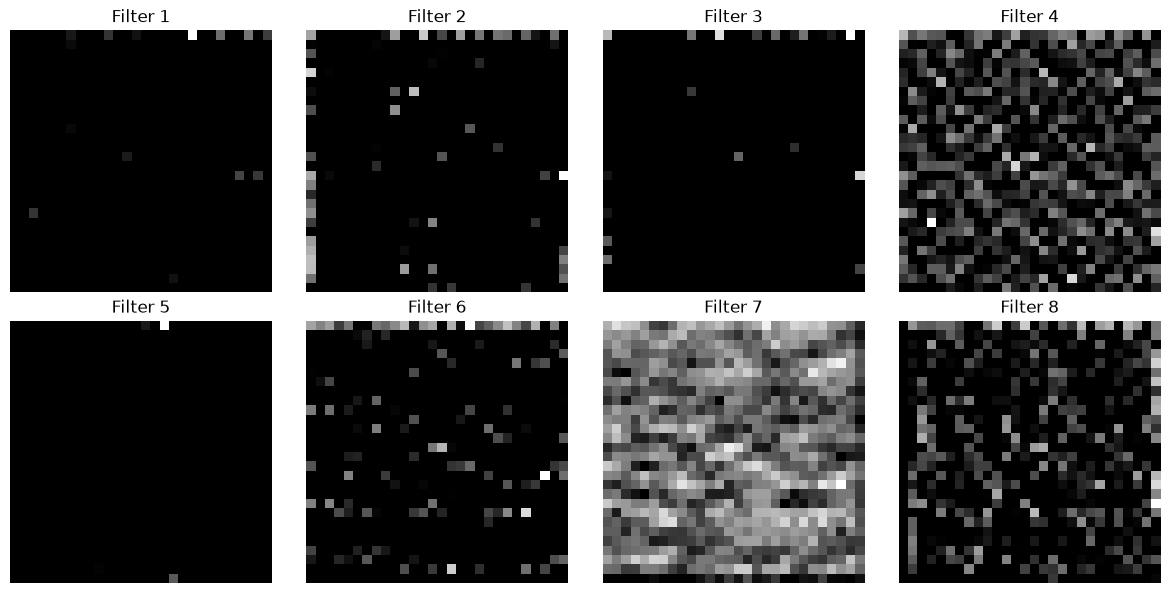

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap="gray")
    plt.axis("off")
    plt.title(f"Filter {i + 1}")

plt.tight_layout()
plt.show()